Importing packages

In [1]:
import pandas as pd #creating feature for the data
import numpy as np #number and arrays
import seaborn as sns #better looking plots
import matplotlib.pyplot as plt #plotting
from sklearn.decomposition import PCA #

from sklearn.preprocessing import StandardScaler #scaling
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score

from sklearn.linear_model import ElasticNet #training linear model
from xgboost import XGBRegressor # training of XGBOOST model
from lightgbm import LGBMRegressor # training light
from sklearn.ensemble import VotingRegressor, StackingRegressor

from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, make_scorer


import warnings
warnings.filterwarnings('ignore')


In [2]:
#imort datasets
train = pd.read_csv(r'C:\Users\ann.kiplimo\OneDrive - Agile Business Solutions\Documents\Mine\MSC\Ngao labs\Capstone project\train (1).csv')

test = pd.read_csv(r'C:\Users\ann.kiplimo\OneDrive - Agile Business Solutions\Documents\Mine\MSC\Ngao labs\Capstone project\test (1).csv')
train

,id,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
0,0,5,8,5,8,6,4,4,3,3,...,5,3,3,5,4,7,5,7,3,0.445
1,1,6,7,4,4,8,8,3,5,4,...,7,2,0,3,5,3,3,4,3,0.450
2,2,6,5,6,7,3,7,1,5,4,...,7,3,7,5,6,8,2,3,3,0.530
3,3,3,4,6,5,4,8,4,7,6,...,2,4,7,4,4,6,5,7,5,0.535
4,4,5,3,2,6,4,4,3,3,3,...,2,2,6,6,4,1,2,3,5,0.415
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1117952,1117952,3,3,4,10,4,5,5,7,10,...,7,8,7,2,2,1,4,6,4,0.495
1117953,1117953,2,2,4,3,9,5,8,1,3,...,9,4,4,3,7,4,9,4,5,0.480
1117954,1117954,7,3,9,4,6,5,9,1,3,...,5,5,5,5,6,5,5,2,4,0.485
1117955,1117955,7,3,3,7,5,2,3,4,6,...,6,8,5,3,4,6,7,6,4,0.495


In [3]:
test

,id,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,...,IneffectiveDisasterPreparedness,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors
0,1117957,4,6,3,5,6,7,8,7,8,...,8,5,7,5,6,3,6,4,4,5
1,1117958,4,4,2,9,5,5,4,7,5,...,2,4,7,4,5,1,7,4,4,3
2,1117959,1,3,6,5,7,2,4,6,4,...,7,9,2,5,5,2,3,6,8,3
3,1117960,2,4,4,6,4,5,4,3,4,...,7,8,4,6,7,6,4,2,4,4
4,1117961,6,3,2,4,6,4,5,5,3,...,4,3,2,6,4,6,8,4,5,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
745300,1863257,5,4,8,3,5,4,4,5,5,...,5,6,1,3,5,6,4,4,6,6
745301,1863258,4,4,2,12,4,3,4,3,5,...,3,7,4,4,3,5,5,3,5,4
745302,1863259,5,7,9,5,5,6,7,5,5,...,6,11,3,11,4,5,9,5,5,4
745303,1863260,4,7,6,3,5,2,3,8,6,...,6,6,8,6,2,3,8,7,5,5


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1117957 entries, 0 to 1117956
Data columns (total 22 columns):
 #   Column                           Non-Null Count    Dtype  
---  ------                           --------------    -----  
 0   id                               1117957 non-null  int64  
 1   MonsoonIntensity                 1117957 non-null  int64  
 2   TopographyDrainage               1117957 non-null  int64  
 3   RiverManagement                  1117957 non-null  int64  
 4   Deforestation                    1117957 non-null  int64  
 5   Urbanization                     1117957 non-null  int64  
 6   ClimateChange                    1117957 non-null  int64  
 7   DamsQuality                      1117957 non-null  int64  
 8   Siltation                        1117957 non-null  int64  
 9   AgriculturalPractices            1117957 non-null  int64  
 10  Encroachments                    1117957 non-null  int64  
 11  IneffectiveDisasterPreparedness  1117957 non-null 

In [5]:
#checking for duplicates
train.duplicated().sum()

0

All the columns are in a numeric data type(int and float), no null values nor duplicates

In [6]:
#
train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,1117957.0,558978.000000,322726.531782,0.000,279489.00,558978.000,838467.00,1117956.000
MonsoonIntensity,1117957.0,4.921450,2.056387,0.000,3.00,5.000,6.00,16.000
TopographyDrainage,1117957.0,4.926671,2.093879,0.000,3.00,5.000,6.00,18.000
RiverManagement,1117957.0,4.955322,2.072186,0.000,4.00,5.000,6.00,16.000
Deforestation,1117957.0,4.942240,2.051689,0.000,4.00,5.000,6.00,17.000
Urbanization,1117957.0,4.942517,2.083391,0.000,3.00,5.000,6.00,17.000
ClimateChange,1117957.0,4.934093,2.057742,0.000,3.00,5.000,6.00,17.000
DamsQuality,1117957.0,4.955878,2.083063,0.000,4.00,5.000,6.00,16.000
Siltation,1117957.0,4.927791,2.065992,0.000,3.00,5.000,6.00,16.000
AgriculturalPractices,1117957.0,4.942619,2.068545,0.000,3.00,5.000,6.00,16.000


For the int variables they have similar characteristics mean and std almost same, same min, 50% and 75% and max almost closed limits. hence they have a similar distribution and we will not use real world flooding knowledge.

In [7]:
#drop id
train = train.drop('id', axis=1)
test = test.drop('id', axis=1)

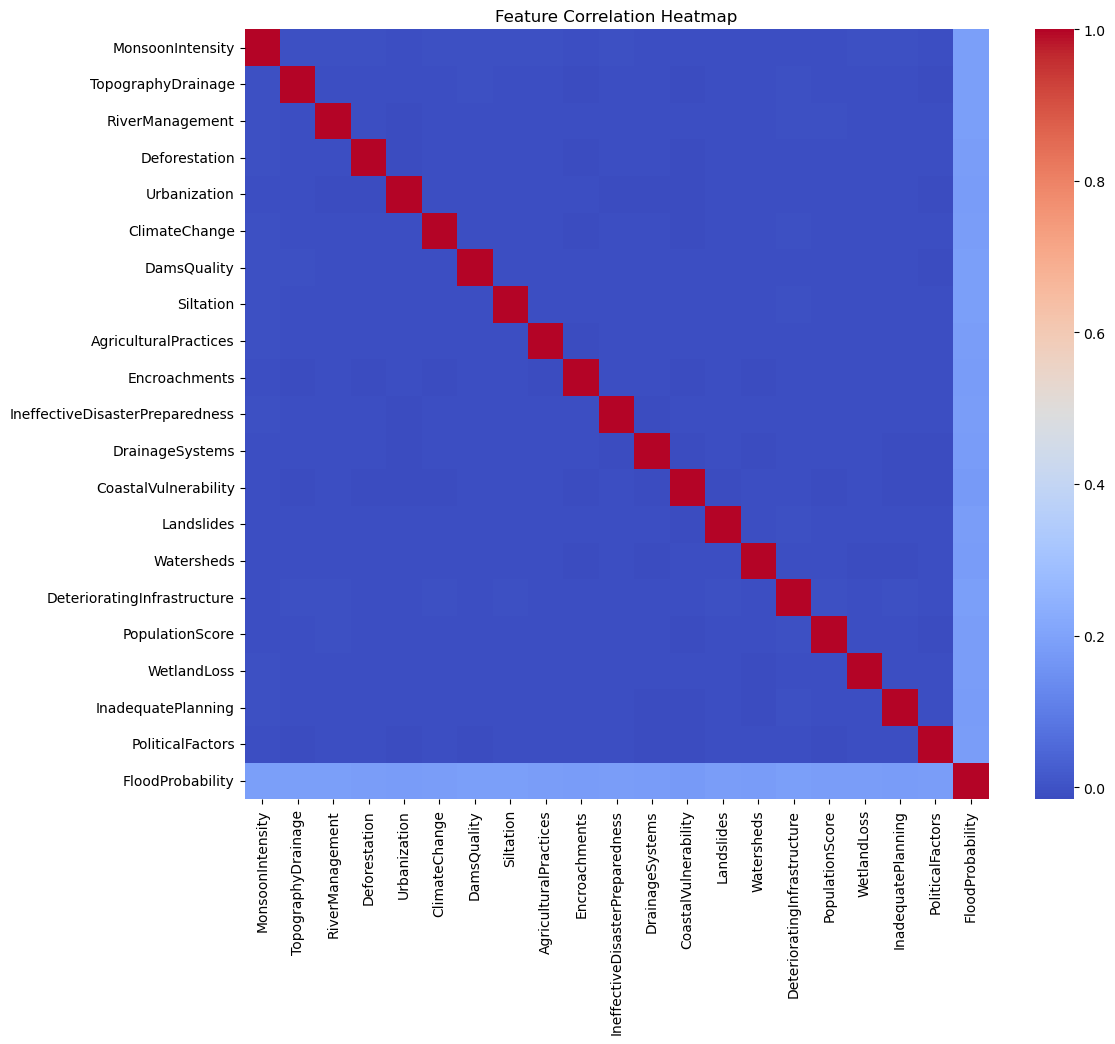

In [8]:
#correlation matrix
plt.figure(figsize=(12,10))

sns.heatmap(
    train.corr(),
    cmap='coolwarm',
    annot=False  # set True if you want numbers
)

plt.title("Feature Correlation Heatmap")
plt.show()

The corr between features are low hence they are not redundant each variable carries unique information hence fit for XGBOOST and LightGBM
The challenge is on the target variable and the features the the corr is low hence nor feature strongly explain flloding on its own therefore we will need to create combination of this features. hence we can say flooding is lnon-linear and flooding depends on interaction between variables.

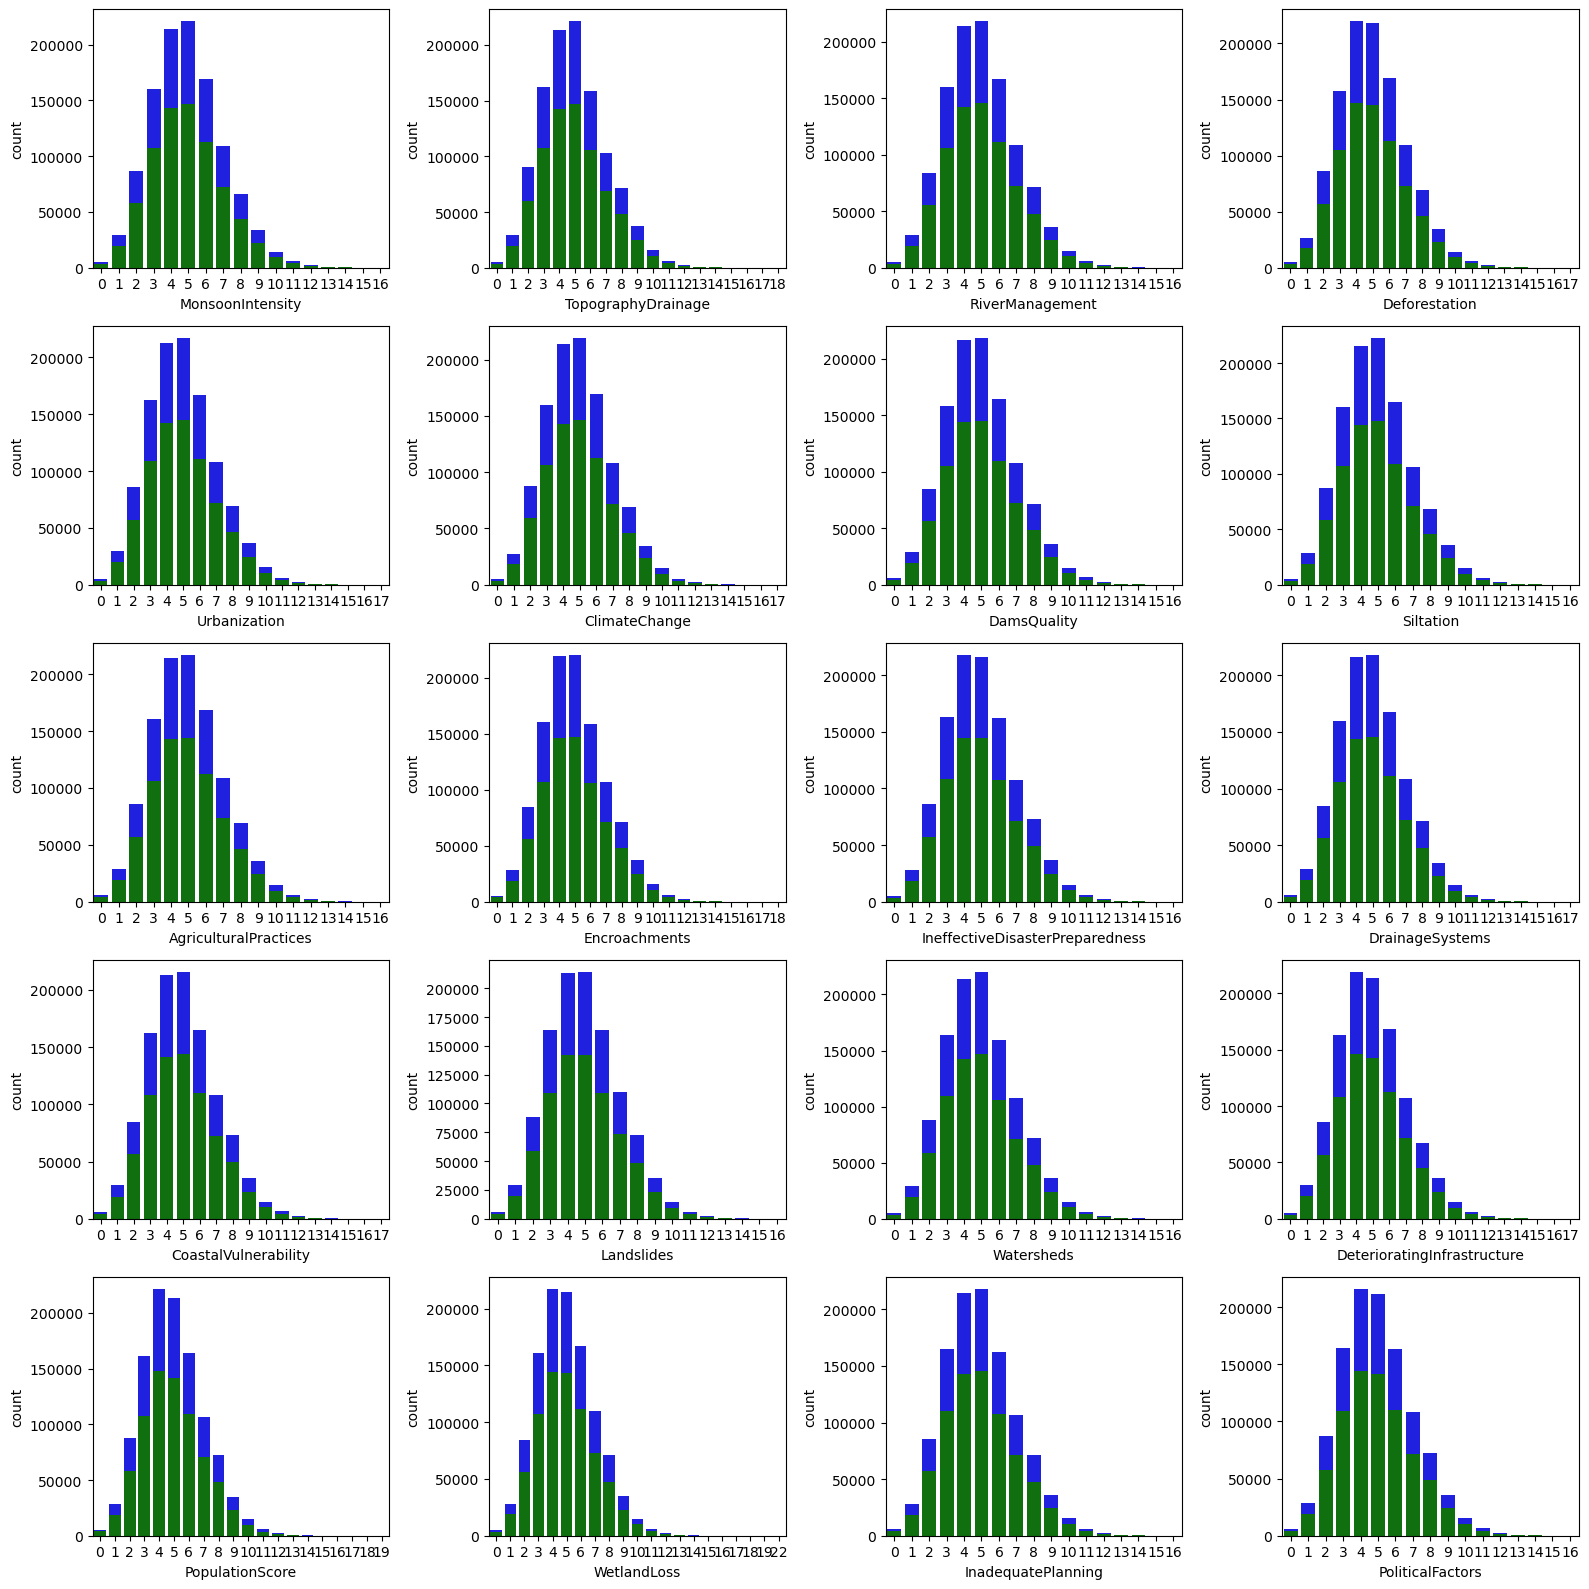

In [9]:
#plotting all the distribution
fig, ax = plt.subplots(5, 4, figsize=(16,16))

for col, a in zip(train.columns[:-1], ax.reshape(-1)):
    sns.barplot(pd.DataFrame(train[col].value_counts()).reset_index(), x=col, y='count', ax = a, color='blue')
    sns.barplot(pd.DataFrame(test[col].value_counts()).reset_index(), x=col, y='count', ax = a, color='green')
plt.tight_layout()
plt.show()

From the plot all the features follows similar distribution

In [10]:
#principle component analysis(PCA)
pca = PCA() #no limit it will create as many components as features
pca.fit(train.iloc[:,:-1])  # takes the all features, finds new axes(directions) that capture max var, -1 is exlusing target var
pca_df = pd.DataFrame({'Explained Variance':pca.explained_variance_ratio_*100, 'Cumulative Explained Variance':np.cumsum(pca.explained_variance_ratio_)*100}) #create the summary table
pca_df['Principal Component'] = list(range(len(pca_df)))
pca_df.head()

,Explained Variance,Cumulative Explained Variance,Principal Component
0,5.154727,5.154727,0
1,5.151653,10.306380,1
2,5.131702,15.438082,2
3,5.107014,20.545097,3
4,5.102997,25.648093,4


Here we are reducing many feature into fewer combined features while keeping most of the information
Explained variance is the % of information captured bt that component, cum exp var is the total % captured up to that point. Now all the components are almost equal hence PCA wont be useful since each original featurecontributes equally to the dataset meaning there is no strong overlap or redundacy. PCA does not significantly reduce dimensionality since nearly all componets are required to retain most of the variance
note: using XGBOOST doest necesarility need PCA

In [11]:
pca_df

,Explained Variance,Cumulative Explained Variance,Principal Component
0,5.154727,5.154727,0
1,5.151653,10.306380,1
2,5.131702,15.438082,2
3,5.107014,20.545097,3
4,5.102997,25.648093,4
5,5.098338,30.746431,5
6,5.083810,35.830241,6
7,5.077164,40.907405,7
8,5.069371,45.976776,8
9,5.056218,51.032994,9


Text(0.5, 1.0, 'PCA Explained Variance')

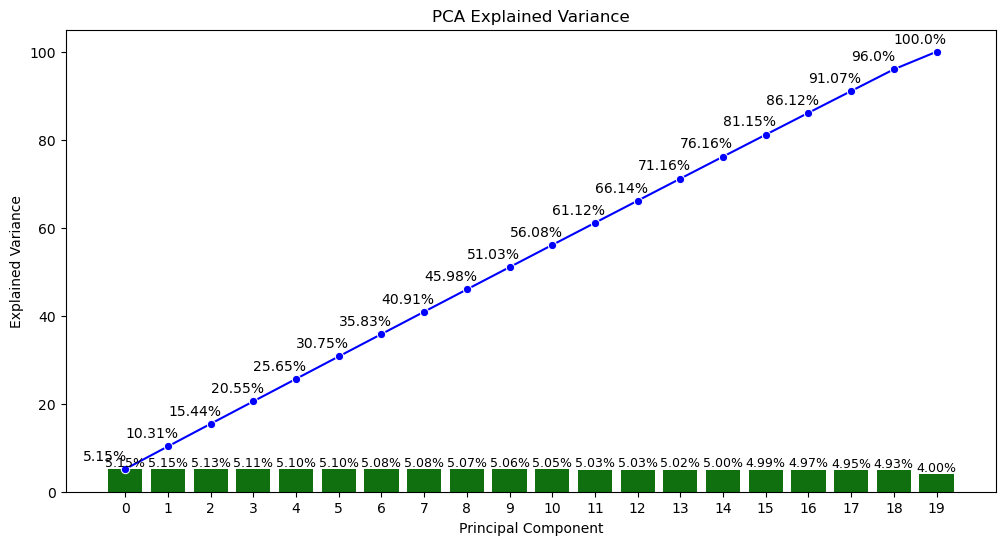

In [12]:
fig, ax = plt.subplots(figsize=(12,6))
sns.barplot(pca_df, x='Principal Component', y='Explained Variance', ax=ax, color='green')
sns.lineplot(pca_df, x='Principal Component', y='Cumulative Explained Variance', ax=ax, marker='o', color='blue')
_ = ax.bar_label(ax.containers[0],fmt='%.2f%%', fontsize=9)
for cev, feature in zip(pca_df['Cumulative Explained Variance'], pca_df['Principal Component']):
    ax.annotate(str(round(cev,2)) + '%', (feature-1, cev+2))
plt.title('PCA Explained Variance')

Text(0.5, 1.0, 'Distribution of Target Flood Probabilities')

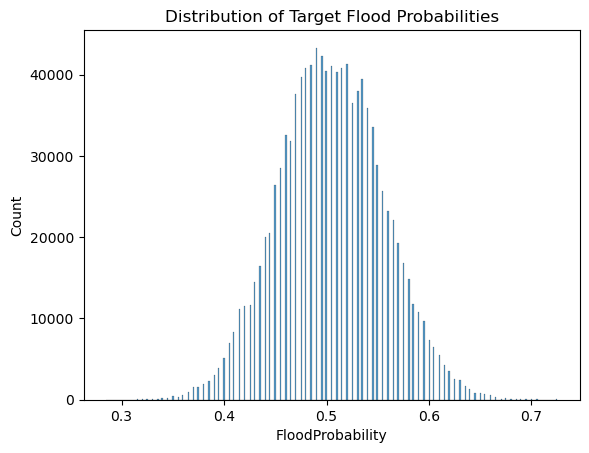

In [13]:
#distribution for target variable
sns.histplot(train['FloodProbability'])
plt.title('Distribution of Target Flood Probabilities')

Target varibale is Normally distributed

FEATURE ENGINEERING(Turning variables)
we are computing statistics across all inputs for each sample to help machinr learning model better undersatnd the patterns of the data by computing global properties of each row

In [14]:
#creating summary feature from multiple columns
#creating a function
#with axis = 1, we are doing row wise feature engineering, For each row combine all flood factors into summary values
def create_new_features(data, cols):
    df = data.copy() #creating a new dataframe and keep the original
    df['sum'] = df[cols].sum(axis=1) # overal flood risk from all factors combined
    df['mean'] = df[cols].mean(axis=1) #typical severity across all feature
    df['median'] = df[cols].median(axis=1) #middle value
    df['max'] = df[cols].max(axis=1) #worse condition, even one extreem factor can trigger flooding
    df['min'] = df[cols].min(axis=1) #best condition
    df['std'] = df[cols].std(axis=1) #how uneven the conditions are
    df['cov'] = df['std']/df['mean'] #how unstable the system is relative to its average
    df['p25'] = df[cols].quantile(0.25, axis=1)
    df['p75'] = df[cols].quantile(0.75, axis=1)
    df['range'] = df['max'] - df['min'] #gap between safest and riskiest factors
    return df

In [15]:
train_new = create_new_features(train, train.columns[:-1]) #takes all columns excluding the last one which is the target column
train_new_only = train_new.drop(train.columns[:-1], axis = 1) #creating new dataset with only the new features

In [16]:
test_new = create_new_features(test, test.columns[:])
test_new_only = test_new.drop(test.columns[:], axis=1)

In [17]:
test_new

,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,...,sum,mean,median,max,min,std,cov,p25,p75,range
0,4,6,3,5,6,7,8,7,8,4,...,111,5.55,5.5,8,3,1.605091,0.289206,4.00,7.00,5
1,4,4,2,9,5,5,4,7,5,4,...,90,4.50,4.0,9,1,1.905670,0.423482,4.00,5.00,8
2,1,3,6,5,7,2,4,6,4,2,...,90,4.50,4.5,9,1,2.259483,0.502107,2.75,6.00,8
3,2,4,4,6,4,5,4,3,4,4,...,92,4.60,4.0,8,2,1.602629,0.348398,4.00,6.00,6
4,6,3,2,4,6,4,5,5,3,7,...,92,4.60,4.5,8,2,1.602629,0.348398,3.75,6.00,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
745300,5,4,8,3,5,4,4,5,5,5,...,94,4.70,5.0,8,1,1.454575,0.309484,4.00,5.25,7
745301,4,4,2,12,4,3,4,3,5,5,...,89,4.45,4.0,12,2,2.089447,0.469539,3.00,5.00,10
745302,5,7,9,5,5,6,7,5,5,3,...,120,6.00,5.0,11,3,2.339591,0.389932,5.00,7.00,8
745303,4,7,6,3,5,2,3,8,6,7,...,107,5.35,6.0,8,2,1.954078,0.365248,3.75,7.00,6


In [18]:
test_new_only

,sum,mean,median,max,min,std,cov,p25,p75,range
0,111,5.55,5.5,8,3,1.605091,0.289206,4.00,7.00,5
1,90,4.50,4.0,9,1,1.905670,0.423482,4.00,5.00,8
2,90,4.50,4.5,9,1,2.259483,0.502107,2.75,6.00,8
3,92,4.60,4.0,8,2,1.602629,0.348398,4.00,6.00,6
4,92,4.60,4.5,8,2,1.602629,0.348398,3.75,6.00,6
...,...,...,...,...,...,...,...,...,...,...
745300,94,4.70,5.0,8,1,1.454575,0.309484,4.00,5.25,7
745301,89,4.45,4.0,12,2,2.089447,0.469539,3.00,5.00,10
745302,120,6.00,5.0,11,3,2.339591,0.389932,5.00,7.00,8
745303,107,5.35,6.0,8,2,1.954078,0.365248,3.75,7.00,6


In [19]:
train_new_only

,FloodProbability,sum,mean,median,max,min,std,cov,p25,p75,range
0,0.445,94,4.70,4.5,8,2,1.750188,0.372380,3.00,5.25,6
1,0.450,94,4.70,4.0,9,0,2.296450,0.488606,3.00,6.25,9
2,0.530,99,4.95,5.0,8,1,1.932411,0.390386,3.00,6.25,7
3,0.535,104,5.20,5.0,8,2,1.641565,0.315686,4.00,6.25,6
4,0.415,72,3.60,3.0,6,1,1.500877,0.416910,2.75,5.00,5
...,...,...,...,...,...,...,...,...,...,...,...
1117952,0.495,99,4.95,4.0,10,1,2.543826,0.513904,3.00,7.00,9
1117953,0.480,96,4.80,4.0,9,1,2.419221,0.504004,3.00,5.50,8
1117954,0.485,98,4.90,5.0,9,1,1.970840,0.402212,4.00,5.25,8
1117955,0.495,99,4.95,5.0,8,2,1.700619,0.343559,3.75,6.00,6


<Axes: >

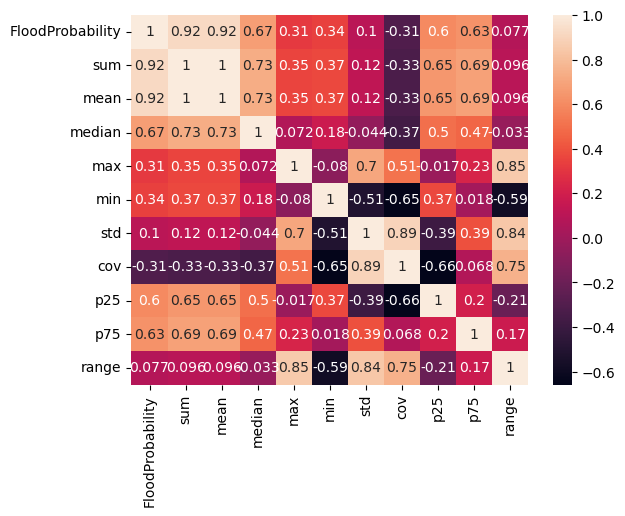

In [20]:
sns.heatmap(train_new_only.corr(), annot=True)

Looking at pairwise linear correlation of the new features and the target, sum and mean values of all the features per sample have a high correlation of 0.92. The remaining features have varying levels of correlation with the target, with only standard deviation and range having a lower correlation coefficient than the original features.

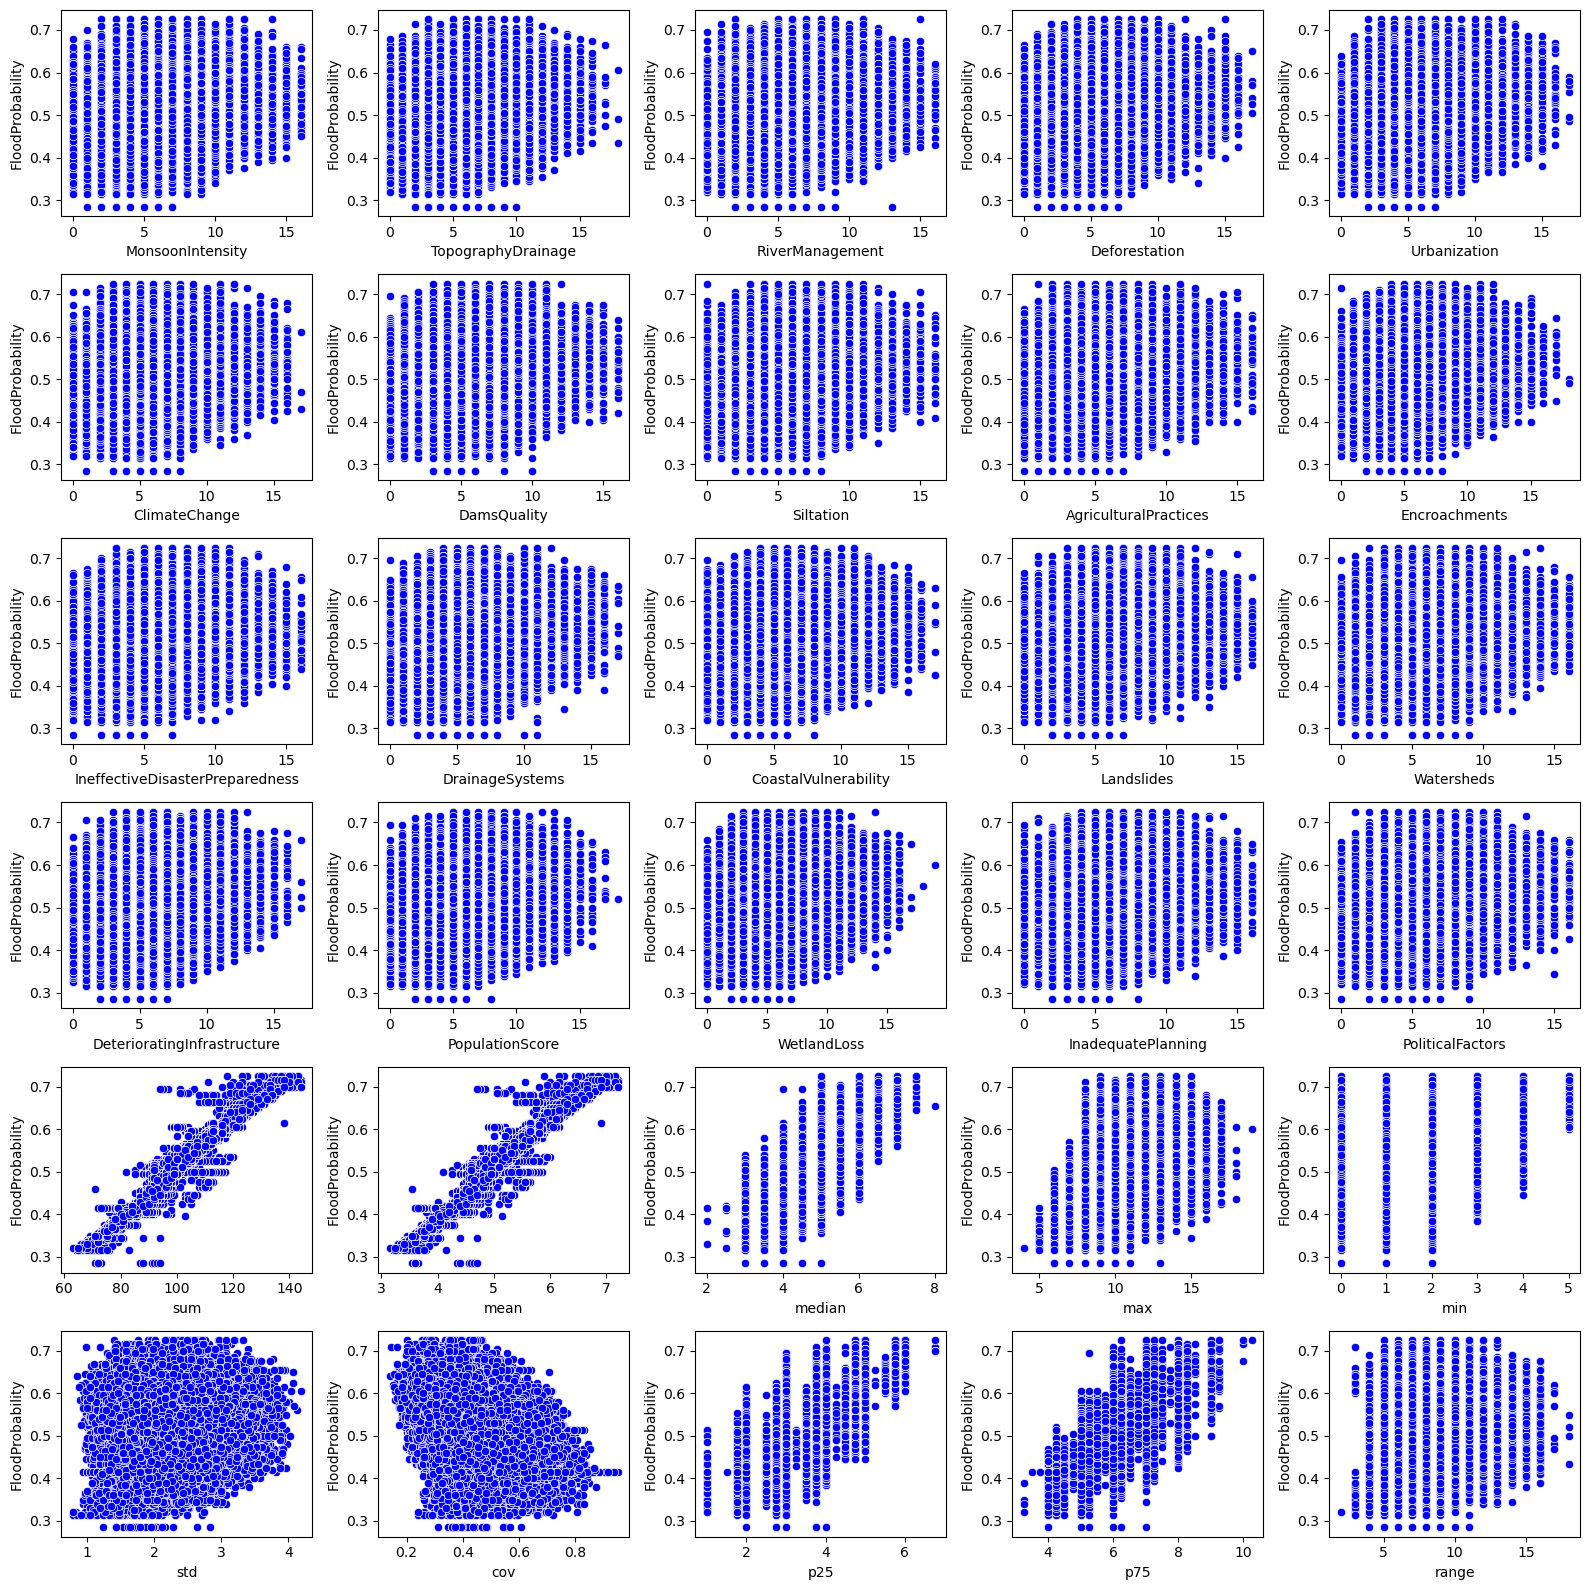

In [21]:
fig, ax = plt.subplots(6, 5, figsize=(16,16))

for col, a in zip(train_new.drop('FloodProbability', axis=1).columns, ax.reshape(-1)):
    sns.scatterplot(train_new[[col,'FloodProbability']], x=col, y='FloodProbability', ax = a, color='blue')
plt.tight_layout()
plt.show()

Looking at scatterplots of all the features we have vs FloodProbability, we are able to see some of the relationships visually. In particular, positive linear correlation is very visible on sum, mean, median, max, ps25, and ps75.

Modelling Setup + hyperparametertuning
Comparing Linear regression- combines Lasso(feature selection) and ridge(shrinkage) Lasso(L10): ideal for feature selection and producing sparse models(fewer variables) and rigde(L2): it handles multicollinearity well and is ideal when most variables are expected to have small impact, 
XGBOOST - builds many decision trees sequentially and learns complex non linear patterns
lightgbm similar to XGBOOST but much faster
 


In [22]:
#Setting up ML regression modelling with three different algorithms along with hyperparameters grids for tuning
#linreg_params is a grid of hyperparameters that can be searched to find the best combination using cross validation
random_state = 47 #ensure reproductivity
#linear regression
linreg = ElasticNet(random_state= random_state) # elasticnet combines lasso and ridge regularization
linreg_params = {'alpha':[0.1,1,10], #alpha controls for overall strength of regularization
                  'l1_ratio':[0.25,0.5,0.75] # controls mix between L1 and L2, 0 = pure ridge(L2), 1= pure lasso (L1), 0.5 = equal mix
}

#XGBOOST regressor
xgb = XGBRegressor(random_state = random_state,
                   objective = 'reg:squarederror',
                   metric = 'r2',
                   device = 'cuda',
                   error_score = 'raise') #raises an error if training fails
xgb_params = {'learning_rate': [0.03, 0.07], #step size for each boosting iteration(smaller)
              'max_depth': [6,9], #controls complexity
              'min_child_weight': [1,10], # minimum sum of instance weight ina child node(prevents overfitting)
              'colsample_bytree' : [0.5,1]} # fraction to use per tree

#LightGBM regressor
lgb = LGBMRegressor(random_state=random_state,
                    metric='r2',
                    verbosity = 1)

lgb_params = {'num_leaves': [10,31], #max leaves per tree(control complexity)
              'learning_rate':[0.01, 0.1], #
              'colsample_bytree': [0.5,1],#fraction of the feature per tree
              'reg_alpha': [0,0.05], #regularization of leaf weight
              'reg_lambda': [0,0.05]} #regularization of leaf weight

#organizing models and parameters
#structure convinient for looping over models during grid search and cross validation
rgs = [
    ('linear Regression', linreg, linreg_params),
    ('GBoost Regressior', xgb, xgb_params),
    ('LGBM Regressor', lgb, lgb_params)
]

#scoring metrics, r2 measures how well predictions fit actual values,
#mea mean squared error
from sklearn.metrics import median_absolute_error
scorer = {
    'r2 score': make_scorer(r2_score),
    'mae_score': make_scorer(mean_squared_error),
}

In [23]:
#we will have two train for new data and the original with additional columns
x_train = train_new.drop('FloodProbability', axis =1)
y_train = train_new['FloodProbability']
x_train_new = train_new_only.drop('FloodProbability', axis =1)
print(x_train.shape)
print(x_train_new)

(1117957, 30)
         sum  mean  median  max  min       std       cov   p25   p75  range
0         94  4.70     4.5    8    2  1.750188  0.372380  3.00  5.25      6
1         94  4.70     4.0    9    0  2.296450  0.488606  3.00  6.25      9
2         99  4.95     5.0    8    1  1.932411  0.390386  3.00  6.25      7
3        104  5.20     5.0    8    2  1.641565  0.315686  4.00  6.25      6
4         72  3.60     3.0    6    1  1.500877  0.416910  2.75  5.00      5
...      ...   ...     ...  ...  ...       ...       ...   ...   ...    ...
1117952   99  4.95     4.0   10    1  2.543826  0.513904  3.00  7.00      9
1117953   96  4.80     4.0    9    1  2.419221  0.504004  3.00  5.50      8
1117954   98  4.90     5.0    9    1  1.970840  0.402212  4.00  5.25      8
1117955   99  4.95     5.0    8    2  1.700619  0.343559  3.75  6.00      6
1117956  110  5.50     5.0    9    1  2.013115  0.366021  4.75  7.00      8

[1117957 rows x 10 columns]


Comparing 3 models under 3 different setups(all features scaled, all features unscaled and engineered only features scaled) and multiple hyperparameters

In [24]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

results = []

# Example multi-metric scoring dictionary
scorer = {
    'r2': 'r2',
    'mae': 'neg_mean_absolute_error'
}

# Loop through models
for rg_name, rg, rg_params in rgs: #each model comes with model object rg and hyperparameter grid(rg_params)

    # Create a fresh GridSearchCV for each model,
    #what this does is it trys all combinations of hyperparameters then perform cross- validation the choose best model
    gs = GridSearchCV(
        estimator=rg,
        param_grid=rg_params,
        scoring=scorer,
        refit='r2',           # refit on R2 metric
        verbose=2,
        error_score='raise',
        return_train_score=True
    )

    # ------------------------------
    # Pipeline A: All features + scaling(normalize)
    pipeline_a = Pipeline([
        ('scaler', StandardScaler()), 
        ('estimator', gs)
    ])
    pipeline_a.fit(x_train, y_train)

    fitted_gs_a = pipeline_a.named_steps['estimator']
    result_a = [
        'All features scaled',
        rg_name,
        fitted_gs_a.best_params_,
        fitted_gs_a.best_score_,
        fitted_gs_a.cv_results_['mean_test_r2'][fitted_gs_a.best_index_],
        -fitted_gs_a.cv_results_['mean_test_mae'][fitted_gs_a.best_index_]  # flip sign
    ]
    results.append(result_a)

    # ------------------------------
    # Pipeline B: All features, no scaling, does scaling really matter for this project?
    gs_b = GridSearchCV(
        estimator=rg,
        param_grid=rg_params,
        scoring=scorer,
        refit='r2',
        verbose=2,
        error_score='raise',
        return_train_score=True
    )

    pipeline_b = Pipeline([
        ('estimator', gs_b)
    ])
    pipeline_b.fit(x_train, y_train)

    fitted_gs_b = pipeline_b.named_steps['estimator']
    result_b = [
        'All features',
        rg_name,
        fitted_gs_b.best_params_,
        fitted_gs_b.best_score_,
        fitted_gs_b.cv_results_['mean_test_r2'][fitted_gs_b.best_index_],
        -fitted_gs_b.cv_results_['mean_test_mae'][fitted_gs_b.best_index_]
    ]
    results.append(result_b)

    # ------------------------------
    # Pipeline C: New features only + scaling
    gs_c = GridSearchCV(
        estimator=rg,
        param_grid=rg_params,
        scoring=scorer,
        refit='r2',
        verbose=2,
        error_score='raise',
        return_train_score=True
    )

    pipeline_c = Pipeline([
        ('scaler', StandardScaler()),
        ('estimator', gs_c)
    ])
    pipeline_c.fit(x_train_new, y_train)

    fitted_gs_c = pipeline_c.named_steps['estimator']
    result_c = [
        'New features scaled',
        rg_name,
        fitted_gs_c.best_params_,
        fitted_gs_c.best_score_,
        fitted_gs_c.cv_results_['mean_test_r2'][fitted_gs_c.best_index_],
        -fitted_gs_c.cv_results_['mean_test_mae'][fitted_gs_c.best_index_]
    ]
    results.append(result_c)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV] END ...........................alpha=0.1, l1_ratio=0.25; total time=   1.5s
[CV] END ...........................alpha=0.1, l1_ratio=0.25; total time=   1.5s
[CV] END ...........................alpha=0.1, l1_ratio=0.25; total time=   2.0s
[CV] END ...........................alpha=0.1, l1_ratio=0.25; total time=   2.4s
[CV] END ...........................alpha=0.1, l1_ratio=0.25; total time=   1.7s
[CV] END ............................alpha=0.1, l1_ratio=0.5; total time=   0.6s
[CV] END ............................alpha=0.1, l1_ratio=0.5; total time=   0.7s
[CV] END ............................alpha=0.1, l1_ratio=0.5; total time=   0.7s
[CV] END ............................alpha=0.1, l1_ratio=0.5; total time=   0.7s
[CV] END ............................alpha=0.1, l1_ratio=0.5; total time=   0.6s
[CV] END ...........................alpha=0.1, l1_ratio=0.75; total time=   0.5s
[CV] END ...........................alpha=0.1, l1

In [25]:
#results from the fold training

results_df = pd.DataFrame(results, columns=[
    'Feature_Set',
    'Model',
    'Best_Params',
    'Best_R2 (CV)',
    'R2',
    'MAE'
])

results_df

,Feature_Set,Model,Best_Params,Best_R2 (CV),R2,MAE
0,All features scaled,linear Regression,"{'alpha': 0.1, 'l1_ratio': 0.25}",0.589445,0.589445,0.027164
1,All features,linear Regression,"{'alpha': 0.1, 'l1_ratio': 0.25}",0.841341,0.841341,0.016213
2,New features scaled,linear Regression,"{'alpha': 0.1, 'l1_ratio': 0.25}",0.589445,0.589445,0.027164
3,All features scaled,GBoost Regressior,"{'colsample_bytree': 1, 'learning_rate': 0.07,...",0.869006,0.869006,0.014332
4,All features,GBoost Regressior,"{'colsample_bytree': 1, 'learning_rate': 0.07,...",0.869006,0.869006,0.014332
5,New features scaled,GBoost Regressior,"{'colsample_bytree': 1, 'learning_rate': 0.07,...",0.869030,0.869030,0.014321
6,All features scaled,LGBM Regressor,"{'colsample_bytree': 1, 'learning_rate': 0.1, ...",0.868775,0.868775,0.014398
7,All features,LGBM Regressor,"{'colsample_bytree': 1, 'learning_rate': 0.1, ...",0.868772,0.868772,0.014399
8,New features scaled,LGBM Regressor,"{'colsample_bytree': 1, 'learning_rate': 0.1, ...",0.868905,0.868905,0.014377


In [26]:
#create view of the parameters
for i in range(len(results_df)):
    print(results_df.loc[i, "Best_Params"])

{'alpha': 0.1, 'l1_ratio': 0.25}
{'alpha': 0.1, 'l1_ratio': 0.25}
{'alpha': 0.1, 'l1_ratio': 0.25}
{'colsample_bytree': 1, 'learning_rate': 0.07, 'max_depth': 9, 'min_child_weight': 10}
{'colsample_bytree': 1, 'learning_rate': 0.07, 'max_depth': 9, 'min_child_weight': 10}
{'colsample_bytree': 1, 'learning_rate': 0.07, 'max_depth': 9, 'min_child_weight': 10}
{'colsample_bytree': 1, 'learning_rate': 0.1, 'num_leaves': 31, 'reg_alpha': 0.05, 'reg_lambda': 0}
{'colsample_bytree': 1, 'learning_rate': 0.1, 'num_leaves': 31, 'reg_alpha': 0, 'reg_lambda': 0.05}
{'colsample_bytree': 1, 'learning_rate': 0.1, 'num_leaves': 31, 'reg_alpha': 0.05, 'reg_lambda': 0.05}


In [151]:
#to see all the features on best_parameters as per the table above
results_df.loc[3, "Best_Params"]

{'colsample_bytree': 1,
 'learning_rate': 0.07,
 'max_depth': 9,
 'min_child_weight': 10}

Best model is XGBOOST with new features only and scaling didnt make much difference
Feature set: New features OR All features
Scaler: Not needed
Params:
- learning_rate = 0.07
- max_depth= 9 (from grid)
- colsample_bytree = 1

In [152]:
x_train.columns

Index(['MonsoonIntensity', 'TopographyDrainage', 'RiverManagement',
       'Deforestation', 'Urbanization', 'ClimateChange', 'DamsQuality',
       'Siltation', 'AgriculturalPractices', 'Encroachments',
       'IneffectiveDisasterPreparedness', 'DrainageSystems',
       'CoastalVulnerability', 'Landslides', 'Watersheds',
       'DeterioratingInfrastructure', 'PopulationScore', 'WetlandLoss',
       'InadequatePlanning', 'PoliticalFactors', 'sum', 'mean', 'median',
       'max', 'min', 'std', 'cov', 'p25', 'p75', 'range'],
      dtype='object')

In [27]:
#running the model on the whole train data only the new features with the parameters
best_model = XGBRegressor(
    learning_rate=0.07,
    max_depth=9,   # or best from grid
    colsample_bytree=1,
    random_state=47
)

best_model.fit(x_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None, colsample_bytree=1,
             device=None, early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.07, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=9, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, ...)

In [28]:
##running the model on the whole train data with ofriginal and the new features with the parameters
from xgboost import XGBRegressor

best_model1 = XGBRegressor(
    learning_rate=0.05,
    max_depth=5,
    n_estimators=500,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
best_model1.fit(x_train_new, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [155]:
test_new.columns

Index(['MonsoonIntensity', 'TopographyDrainage', 'RiverManagement',
       'Deforestation', 'Urbanization', 'ClimateChange', 'DamsQuality',
       'Siltation', 'AgriculturalPractices', 'Encroachments',
       'IneffectiveDisasterPreparedness', 'DrainageSystems',
       'CoastalVulnerability', 'Landslides', 'Watersheds',
       'DeterioratingInfrastructure', 'PopulationScore', 'WetlandLoss',
       'InadequatePlanning', 'PoliticalFactors', 'sum', 'mean', 'median',
       'max', 'min', 'std', 'cov', 'p25', 'p75', 'range'],
      dtype='object')

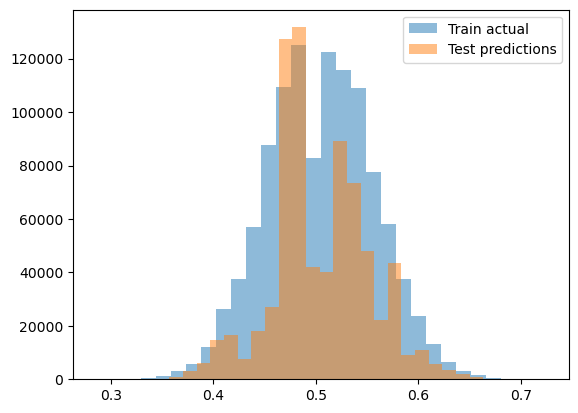

In [30]:
#Prediction on the whole data with both original and new features
test_preds = best_model.predict(test_new)

#plot comparing the predicted and the train target values 
import matplotlib.pyplot as plt

plt.hist(y_train, bins=30, alpha=0.5, label="Train actual")
plt.hist(test_preds, bins=30, alpha=0.5, label="Test predictions")
plt.legend()
plt.show()

In [ ]:
#comparing columns for train and test
x_train.columns == test_new.columns

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True])

In [ ]:
test_new.columns

Index(['id', 'MonsoonIntensity', 'TopographyDrainage', 'RiverManagement',
       'Deforestation', 'Urbanization', 'ClimateChange', 'DamsQuality',
       'Siltation', 'AgriculturalPractices', 'Encroachments',
       'IneffectiveDisasterPreparedness', 'DrainageSystems',
       'CoastalVulnerability', 'Landslides', 'Watersheds',
       'DeterioratingInfrastructure', 'PopulationScore', 'WetlandLoss',
       'InadequatePlanning', 'PoliticalFactors', 'sum', 'mean', 'median',
       'max', 'min', 'std', 'cov', 'p25', 'p75', 'range'],
      dtype='object')

In [31]:
#model prediction on the test data with only new features

test_preds1 = best_model1.predict(test_new_only)

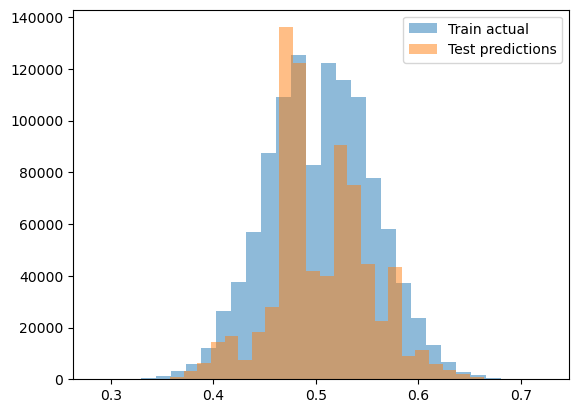

In [32]:
#plot comparing the predicted and the train target values 
import matplotlib.pyplot as plt

plt.hist(y_train, bins=30, alpha=0.5, label="Train actual")
plt.hist(test_preds1, bins=30, alpha=0.5, label="Test predictions")
plt.legend()
plt.show()

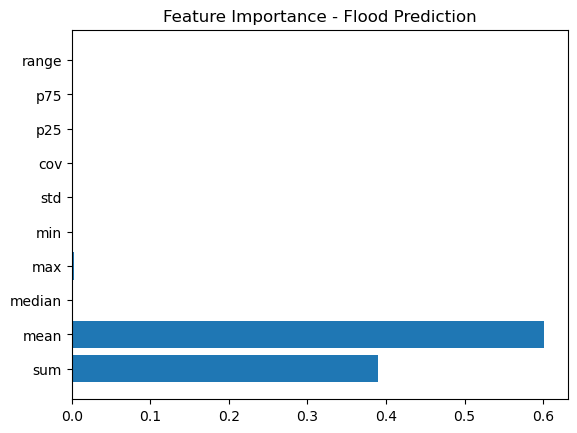

In [35]:
#Feature importance
import matplotlib.pyplot as plt

plt.figure()
plt.barh(x_train_new.columns, best_model1.feature_importances_)
plt.title("Feature Importance - Flood Prediction")
plt.show()

In [161]:
#checking feature importance without sum
features_to_drop = ['sum']
X_train_new = x_train.drop(columns=features_to_drop)

best_model.fit(x_train_new, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

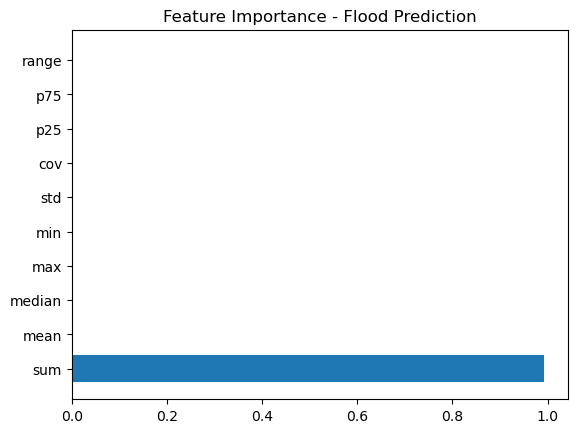

In [180]:
#Feature importance
import matplotlib.pyplot as plt

plt.figure()
plt.barh(x_train_new.columns, best_model1.feature_importances_)
plt.title("Feature Importance - Flood Prediction")
plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Flood Probability")
plt.ylabel("Predicted Flood Probability")
plt.title("GBoost Model Predictions")
plt.show()

In [ ]:
# Extract training data
X_train_best = x_train_new  # match pipeline_c features
y_train_best = y_train

# Fit pipeline_c (XGBoost + scaling)
pipeline_c.fit(X_train_best, y_train_best)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
[LightGBM] [Warning] Unknown parameter: Lerning_rate
[LightGBM] [Warning] Unknown parameter: Lerning_rate
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002678 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 749
[LightGBM] [Info] Number of data points in the train set: 894365, number of used features: 10
[LightGBM] [Info] Start training from score 0.504471
[LightGBM] [Warning] Unknown parameter: Lerning_rate
[LightGBM] [Warning] Unknown parameter: Lerning_rate
[CV] END Lerning_rate=0.01, colsample_bytree=0.5, num_leaves=10, reg_alpha=0, reg_lambda=0; total time=   0.9s
[LightGBM] [Warning] Unknown parameter: Lerning_rate
[LightGBM] [Warning] Unknown parameter: Lerning_rate
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004532 seconds.

Pipeline(steps=[('scaler', StandardScaler()),
                ('estimator',
                 GridSearchCV(error_score='raise',
                              estimator=LGBMRegressor(metric='r2',
                                                      random_state=47,
                                                      verbosity=1),
                              param_grid={'Lerning_rate': [0.01, 0.1],
                                          'colsample_bytree': [0.5, 1],
                                          'num_leaves': [10, 31],
                                          'reg_alpha': [0, 0.05],
                                          'reg_lambda': [0, 0.05]},
                              refit='r2', return_train_score=True,
                              scoring={'mae': 'neg_mean_absolute_error',
                                       'r2': 'r2'},
                              verbose=2))])

In [ ]:
agg_features = ['sum', 'mean', 'median', 'max', 'min', 'std', 'cov', 'p25', 'p75', 'range']

X_train_clean = x_train.drop(columns=agg_features)
X_test_clean = test_new.drop(columns=agg_features + ['id'])

In [ ]:
best_model.fit(X_train_clean, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None, colsample_bytree=1,
             device=None, early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.07, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=9, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, ...)

In [ ]:
from xgboost import XGBRegressor

model = XGBRegressor(
    learning_rate=0.05,
    max_depth=5,
    n_estimators=500,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [ ]:
model.fit(X_train_clean, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
import pandas as pd

# Get importance
importance = model.feature_importances_

# Create DataFrame
feat_imp = pd.DataFrame({
    'feature': X_train_clean.columns,
    'importance': importance
})

# Sort
feat_imp = feat_imp.sort_values(by='importance', ascending=False)

print(feat_imp.head(10))

                        feature  importance
15  DeterioratingInfrastructure    0.054471
0              MonsoonIntensity    0.052608
6                   DamsQuality    0.052063
7                     Siltation    0.051723
17                  WetlandLoss    0.051584
2               RiverManagement    0.051552
8         AgriculturalPractices    0.051509
5                 ClimateChange    0.050876
16              PopulationScore    0.050756
3                 Deforestation    0.050742


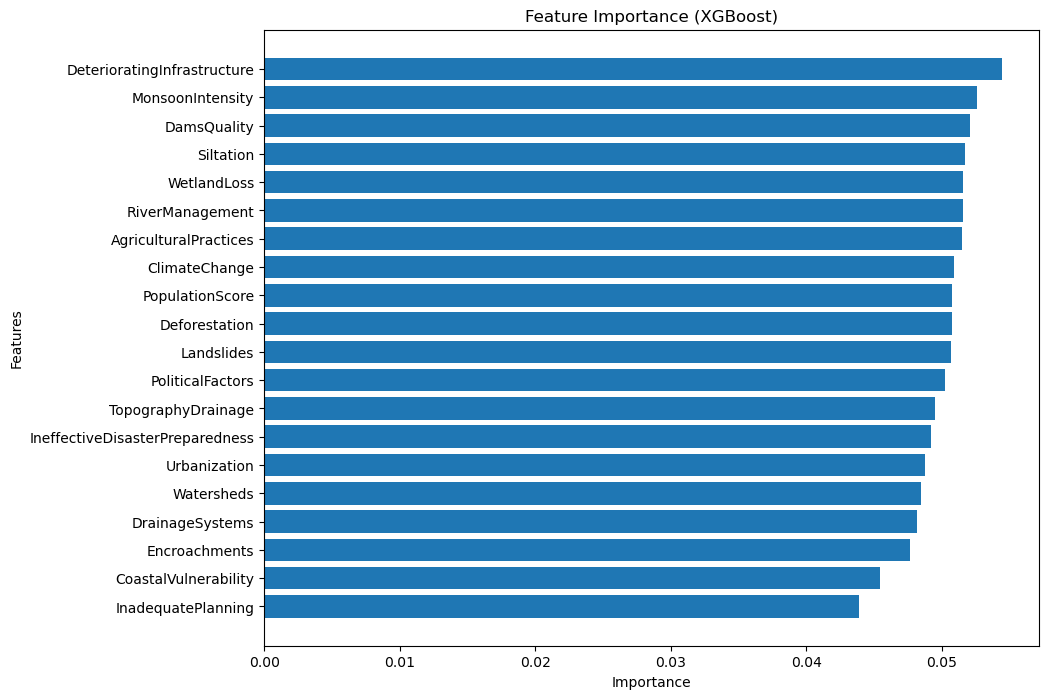

In [ ]:
import matplotlib.pyplot as plt

# Sort for plotting
feat_imp_sorted = feat_imp.sort_values(by='importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(feat_imp_sorted['feature'], feat_imp_sorted['importance'])
plt.title("Feature Importance (XGBoost)")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

In [ ]:
import pandas as pd

importance = best_model.feature_importances_
feat_imp = pd.Series(importance, index=x_train.columns).sort_values(ascending=False)

print(feat_imp.head(10))

sum       0.558716
mean      0.388194
median    0.018282
p75       0.008345
p25       0.007284
max       0.006656
std       0.001588
range     0.001489
min       0.001449
cov       0.001247
dtype: float32


In [ ]:
random_state = 47

models = {
    "ElasticNet": {
        "model": ElasticNet(random_state=random_state),
        "params": {
            "alpha": [0.1, 1, 10],
            "l1_ratio": [0.25, 0.5, 0.75]
        },
        "scale": True
    },

    "XGBoost": {
        "model": XGBRegressor(
            random_state=random_state,
            objective="reg:squarederror",
            tree_method="hist"
        ),
        "params": {
            "learning_rate": [0.03, 0.07],
            "max_depth": [6, 9],
            "min_child_weight": [1, 10],
            "colsample_bytree": [0.5, 1]
        },
        "scale": False
    },

    "LightGBM": {
        "model": LGBMRegressor(random_state=random_state),
        "params": {
            "num_leaves": [10, 31],
            "learning_rate": [0.01, 0.1],
            "colsample_bytree": [0.5, 1],
            "reg_alpha": [0, 0.05],
            "reg_lambda": [0, 0.05]
        },
        "scale": False
    }
}

In [ ]:

results = []

datasets = {
    "All features": x_train,
    "Engineered only": x_train_new
}

for data_name, X in datasets.items(): #looping though the two datasets

    for model_name, config in models.items(): #loop through all models

        steps = [] #creating an empty list to build a pipeline

        # add scaling ONLY if needed
        if config["scale"]:
            steps.append(("scaler", StandardScaler()))

        steps.append(("model", config["model"]))

        pipeline = Pipeline(steps) #as per the model we created earlier

        gs = GridSearchCV(
            estimator=pipeline, #turning the whole pipeline
            param_grid={"model__" + k: v for k, v in config["params"].items()}, #attachhing the model with the parameters
            scoring=scorer, #evauates the model
            refit="r2", #picks the best model
            cv=5, #splits data into 5
            verbose=1, #prints progress during training
            error_score="raise", #
            return_train_score=True #helps on detetcing overfitting
        )

        gs.fit(X, y_train)

        results.append([
            data_name,
            model_name,
            gs.best_params_,
            gs.best_score_,
            -gs.cv_results_["mean_test_mae"][gs.best_index_]
        ])

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Fitting 5 folds for each of 32 candidates, totalling 160 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008135 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1097
[LightGBM] [Info] Number of data points in the train set: 894365, number of used features: 30
[LightGBM] [Info] Start training from score 0.504471
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.051771 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1104
[LightGBM] [Info] Number of data points in the train set: 894365, number of used features: 30
[LightGBM] [Info] Start training from score 0.504463
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overh

In [ ]:
import pandas as pd

results_df = pd.DataFrame(
    results,
    columns=[
        "Dataset",
        "Model",
        "Best Params",
        "Best R2",
        "MAE"
    ]
)

results_df.sort_values(by="Best R2", ascending=False)

,Dataset,Model,Best Params,Best R2,MAE
4,Engineered only,XGBoost,"{'model__colsample_bytree': 1, 'model__learnin...",0.869030,0.014321
1,All features,XGBoost,"{'model__colsample_bytree': 1, 'model__learnin...",0.869006,0.014332
5,Engineered only,LightGBM,"{'model__colsample_bytree': 1, 'model__learnin...",0.868895,0.014377
2,All features,LightGBM,"{'model__colsample_bytree': 1, 'model__learnin...",0.868772,0.014399
0,All features,ElasticNet,"{'model__alpha': 0.1, 'model__l1_ratio': 0.25}",0.589447,0.027164
3,Engineered only,ElasticNet,"{'model__alpha': 0.1, 'model__l1_ratio': 0.25}",0.589447,0.027164


In [ ]:
for i in range(len(results_df)):
    print(results_df.loc[i, "Best Params"])

{'model__alpha': 0.1, 'model__l1_ratio': 0.25}
{'model__colsample_bytree': 1, 'model__learning_rate': 0.07, 'model__max_depth': 9, 'model__min_child_weight': 10}
{'model__colsample_bytree': 1, 'model__learning_rate': 0.1, 'model__num_leaves': 31, 'model__reg_alpha': 0, 'model__reg_lambda': 0.05}
{'model__alpha': 0.1, 'model__l1_ratio': 0.25}
{'model__colsample_bytree': 1, 'model__learning_rate': 0.07, 'model__max_depth': 9, 'model__min_child_weight': 10}
{'model__colsample_bytree': 1, 'model__learning_rate': 0.1, 'model__num_leaves': 31, 'model__reg_alpha': 0.05, 'model__reg_lambda': 0}


In [ ]:
final_model = XGBRegressor(
    colsample_bytree=1,
    learning_rate=0.07,   # use best params you found
    max_depth=10,
    min_child_weight=3,
    subsample = 0.9,
    n_estimator = 300,
    random_state=47
)

final_model.fit(x_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None, colsample_bytree=1,
             device=None, early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.07, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=10, max_leaves=None,
             min_child_weight=3, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimator=300, n_estimators=None,
             n_jobs=None, ...)

In [ ]:
# from sklearn.model_selection import train_test_split

# X_train, X_val, y_train, y_val = train_test_split(
#     x_train,
#     y_train,
#     test_size=0.2,
#     random_state=47
# )

In [ ]:
# final_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None, colsample_bytree=1,
             device=None, early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.07, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=9, max_leaves=None,
             min_child_weight=10, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, ...)

In [ ]:
# preds = final_model.predict(X_val)

In [ ]:
# from sklearn.metrics import r2_score, mean_absolute_error

# print("R2:", r2_score(y_val, preds))
# print("MAE:", mean_absolute_error(y_val, preds))

R2: 0.8696560665395948
MAE: 0.014291941570213707


In [ ]:
x_train.columns

Index(['MonsoonIntensity', 'TopographyDrainage', 'RiverManagement',
       'Deforestation', 'Urbanization', 'ClimateChange', 'DamsQuality',
       'Siltation', 'AgriculturalPractices', 'Encroachments',
       'IneffectiveDisasterPreparedness', 'DrainageSystems',
       'CoastalVulnerability', 'Landslides', 'Watersheds',
       'DeterioratingInfrastructure', 'PopulationScore', 'WetlandLoss',
       'InadequatePlanning', 'PoliticalFactors', 'sum', 'mean', 'median',
       'max', 'min', 'std', 'cov', 'p25', 'p75', 'range'],
      dtype='object')

In [ ]:
test_preds1 = final_model.predict(testnew)

In [ ]:
test_preds

array([0.70482206, 0.6984316 , 0.69744545, ..., 0.705728  , 0.6952201 ,
       0.6926758 ], dtype=float32)

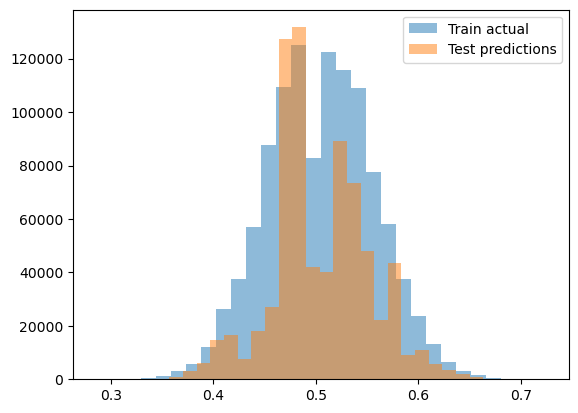

In [37]:
import matplotlib.pyplot as plt

plt.hist(y_train, bins=30, alpha=0.5, label="Train actual")
plt.hist(test_preds, bins=30, alpha=0.5, label="Test predictions")
plt.legend()
plt.show()

In [ ]:
train.describe()


,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
count,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,...,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06
mean,4.921450e+00,4.926671e+00,4.955322e+00,4.942240e+00,4.942517e+00,4.934093e+00,4.955878e+00,4.927791e+00,4.942619e+00,4.949230e+00,...,4.946893e+00,4.953999e+00,4.931376e+00,4.929032e+00,4.925907e+00,4.927520e+00,4.950859e+00,4.940587e+00,4.939004e+00,5.044803e-01
std,2.056387e+00,2.093879e+00,2.072186e+00,2.051689e+00,2.083391e+00,2.057742e+00,2.083063e+00,2.065992e+00,2.068545e+00,2.083324e+00,...,2.072333e+00,2.088899e+00,2.078287e+00,2.082395e+00,2.064813e+00,2.074176e+00,2.068696e+00,2.081123e+00,2.090350e+00,5.102610e-02
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.850000e-01
25%,3.000000e+00,3.000000e+00,4.000000e+00,4.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,...,4.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,3.000000e+00,3.000000e+00,4.700000e-01
50%,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,...,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.050000e-01
75%,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,...,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,5.400000e-01
max,1.600000e+01,1.800000e+01,1.600000e+01,1.700000e+01,1.700000e+01,1.700000e+01,1.600000e+01,1.600000e+01,1.600000e+01,1.800000e+01,...,1.700000e+01,1.700000e+01,1.600000e+01,1.600000e+01,1.700000e+01,1.800000e+01,1.900000e+01,1.600000e+01,1.600000e+01,7.250000e-01


In [ ]:
test.describe()

,id,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,...,IneffectiveDisasterPreparedness,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors
count,7.453050e+05,745305.000000,745305.000000,745305.000000,745305.000000,745305.000000,745305.000000,745305.000000,745305.000000,745305.000000,...,745305.000000,745305.000000,745305.000000,745305.000000,745305.000000,745305.000000,745305.000000,745305.000000,745305.000000,745305.000000
mean,1.490609e+06,4.915610,4.930288,4.960027,4.946084,4.938424,4.933524,4.958468,4.927651,4.945308,...,4.947436,4.944003,4.957209,4.927620,4.930720,4.926062,4.926957,4.948424,4.940204,4.943918
std,2.151512e+05,2.056295,2.094117,2.071722,2.052602,2.081816,2.059243,2.089312,2.068110,2.073404,...,2.081322,2.072335,2.088787,2.079006,2.083348,2.065638,2.073692,2.065891,2.079128,2.087387
min,1.117957e+06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.304283e+06,3.000000,3.000000,4.000000,4.000000,3.000000,3.000000,4.000000,3.000000,3.000000,...,3.000000,4.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,3.000000,3.000000
50%,1.490609e+06,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
75%,1.676935e+06,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,...,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000
max,1.863261e+06,16.000000,17.000000,16.000000,17.000000,17.000000,17.000000,16.000000,16.000000,16.000000,...,16.000000,17.000000,17.000000,16.000000,16.000000,17.000000,19.000000,22.000000,16.000000,16.000000


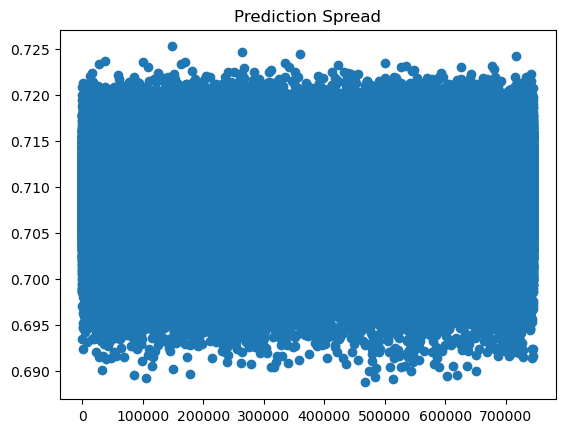

In [ ]:
plt.scatter(range(len(test_preds)), test_preds)
plt.title("Prediction Spread")
plt.show()